<div dir="rtl">

## فصل ۷: یادگیری نظارت شده - طبقه‌بندی با استفاده از رگرسیون لجستیک

## رگرسیون لجستیک چیست؟

در فصل قبل، با رگرسیون خطی و نحوه استفاده از آن برای پیش‌بینی مقادیر آینده آشنا شدید. در این فصل، با الگوریتم یادگیری نظارت شده دیگری به نام رگرسیون لجستیک آشنا می‌شوید. برخلاف رگرسیون خطی، رگرسیون لجستیک سعی در پیش‌بینی مقدار یک متغیر عددی با توجه به مجموعه‌ای از ورودی‌ها ندارد. در عوض، خروجی رگرسیون لجستیک، احتمال تعلق یک نقطه ورودی به یک کلاس خاص است. خروجی رگرسیون لجستیک همیشه در بازه [0,1] قرار دارد.

برای درک کاربرد رگرسیون لجستیک، مثال نشان داده شده در تصویر ۷.۱ را در نظر بگیرید. فرض کنید یک مجموعه داده حاوی اطلاعات درآمد رأی‌دهندگان و ترجیحات رأی آن‌ها دارید. برای این مجموعه داده، می‌بینید که رأی‌دهندگان با درآمد پایین تمایل به رأی دادن به نامزد B دارند، در حالی که رأی‌دهندگان با درآمد بالا تمایل به نامزد A دارند.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-1.png" width="700" height="450">
</div>



<div dir="rtl">

با این مجموعه داده، شما بسیار علاقه‌مند خواهید بود که سعی کنید پیش‌بینی کنید که رأی‌دهندگان آینده بر اساس سطح درآمد خود به کدام نامزد رأی خواهند داد. در نگاه اول، ممکن است وسوسه شوید که آنچه را که تازه یاد گرفته‌اید را برای این مسئله اعمال کنید؛ یعنی استفاده از رگرسیون خطی. تصویر ۷.۲ نشان می‌دهد که وقتی رگرسیون خطی را برای این مسئله اعمال می‌کنید، چه شکلی می‌شود.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-2.png" width="700" height="450">
</div>



<div dir="rtl">

مشکل اصلی رگرسیون خطی این است که مقدار پیش‌بینی شده همیشه در محدوده مورد انتظار قرار نمی‌گیرد. مورد رأی‌دهنده با درآمد بسیار پایین (نزدیک به صفر) را در نظر بگیرید، و از نمودار می‌بینید که نتیجه پیش‌بینی شده یک مقدار منفی است. آنچه شما واقعاً می‌خواهید، راهی است که پیش‌بینی را به عنوان مقداری از ۰ تا ۱ برگرداند، جایی که این مقدار نشان‌دهنده احتمال وقوع یک رویداد است.

تصویر ۷.۳ نشان می‌دهد که چگونه رگرسیون لجستیک این مشکل را حل می‌کند. به جای رسم یک خط راست که از نقاط عبور می‌کند، اکنون از یک خط منحنی استفاده می‌کنید تا سعی کنید تمام نقاط نمودار را برازش دهید.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-3.png" width="700" height="450">
</div>



<div dir="rtl">

با استفاده از رگرسیون لجستیک، خروجی مقداری از ۰ تا ۱ خواهد بود، جایی که هر چیزی کمتر از (یا مساوی) ۰.۵ (معروف به آستانه) به عنوان رأی به نامزد B در نظر گرفته می‌شود، و هر چیزی بیشتر از ۰.۵ به عنوان رأی به نامزد A در نظر گرفته می‌شود.

## درک شانس (Odds)

قبل از بحث در مورد جزئیات الگوریتم رگرسیون لجستیک، ابتدا باید در مورد یک اصطلاح مهم بحث کنیم: شانس. شانس به عنوان نسبت احتمال موفقیت به احتمال شکست تعریف می‌شود.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-4.png" width="400" height="200">
</div>



<div dir="rtl">

به عنوان مثال، شانس به دست آوردن شیر هنگام پرتاب سکه ۱ است. این به این دلیل است که احتمال ۰.۵ برای به دست آوردن شیر و احتمال ۰.۵ برای به دست آوردن خط دارید. وقتی می‌گویید شانس به دست آوردن شیر ۱ است، به این معنی است که ۵۰ درصد شانس به دست آوردن شیر دارید.

اما اگر سکه به گونه‌ای دستکاری شده باشد که احتمال به دست آوردن شیر ۰.۸ و احتمال به دست آوردن خط ۰.۲ باشد، آنگاه شانس به دست آوردن شیر برابر با ۰.۸/۰.۲ = ۴ است. یعنی شما ۴ برابر بیشتر از خط، احتمال به دست آوردن شیر دارید. به همین ترتیب، شانس به دست آوردن خط ۰.۲/۰.۸ = ۰.۲۵ است.

## تابع Logit

هنگامی که تابع لگاریتم طبیعی را روی شانس اعمال می‌کنید، تابع logit را به دست می‌آورید. تابع logit لگاریتم شانس است.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-5.png" width="400" height="150">
</div>



<div dir="rtl">

تابع logit یک متغیر در (0,1) را به یک متغیر جدید در (−∞,∞) تبدیل می‌کند. برای مشاهده این رابطه، می‌توانید از قطعه کد زیر استفاده کنید.
</div>

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def logit(x):
    return np.log( x / (1 - x) )

x = np.arange(0.001,0.999, 0.0001)
y = [logit(n) for n in x]
plt.plot(x,y)
plt.xlabel("Probability")
plt.ylabel("Logit - L")


<div dir="rtl">

## منحنی سیگموئید

برای منحنی logit، توجه کنید که محور x احتمال و محور y محدوده اعداد حقیقی است. برای رگرسیون لجستیک، آنچه واقعاً می‌خواهید تابعی است که اعداد را در سیستم اعداد حقیقی به احتمالات نگاشت می‌کند، که دقیقاً همان چیزی است که وقتی محورهای منحنی logit را برعکس می‌کنید به دست می‌آورید.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-7.png" width="700" height="450">
</div>



<div dir="rtl">

هنگامی که محورها را برعکس می‌کنید، منحنی‌ای که به دست می‌آورید منحنی سیگموئید نامیده می‌شود. منحنی سیگموئید با استفاده از تابع سیگموئید به دست می‌آید، که معکوس تابع logit است. تابع سیگموئید برای تبدیل مقادیر در (−∞,∞) به اعداد در (0,1) استفاده می‌شود.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-8.png" width="400" height="150">
</div>



<div dir="rtl">

قطعه کد زیر نشان می‌دهد که چگونه منحنی سیگموئید به دست می‌آید.
</div>

In [ ]:
def sigmoid(x):
    return (1 / (1 + np.exp(-x)))

x = np.arange(-10, 10, 0.0001)
y = [sigmoid(n) for n in x]
plt.plot(x,y)
plt.xlabel("Logit - L")
plt.ylabel("Probability")


<div dir="rtl">
درست مانند تلاش برای رسم یک خط راست که از تمام نقاط در رگرسیون خطی عبور می‌کند (همانطور که در فصل ۵ توضیح داده شد)، در رگرسیون لجستیک نیز می‌خواهیم یک منحنی سیگموئید را رسم کنیم که از تمام نقاط عبور کند. از نظر ریاضی، این را می‌توان با فرمول نشان داده شده در تصویر ۷.۱۰ بیان کرد.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-10.png" width="500" height="150">
</div>



<div dir="rtl">

توجه کنید که تفاوت کلیدی بین فرمول نشان داده شده در تصاویر ۷.۸ و ۷.۱۰ این است که اکنون L با β0 و xβ جایگزین شده است. ضرایب β0 و β ناشناخته هستند و باید بر اساس داده‌های آموزشی موجود با استفاده از تکنیکی به نام حداکثر درست‌نمایی (MLE) تخمین زده شوند. در رگرسیون لجستیک، β0 به عنوان عرض از مبدا (intercept) و xβ به عنوان ضریب (coefficient) شناخته می‌شود.

# استفاده از مجموعه داده سرطان سینه ویسکانسین (تشخیصی)

Scikit-learn همراه با مجموعه داده سرطان سینه ویسکانسین (تشخیصی) است. این یک مجموعه داده کلاسیک است که اغلب برای نشان دادن طبقه‌بندی دودویی استفاده می‌شود. این مجموعه داده شامل ۳۰ ویژگی است که از یک تصویر دیجیتالی شده از نمونه آسپیراسیون سوزنی ظریف (FNA) از یک توده سینه محاسبه شده‌اند. برچسب مجموعه داده یک طبقه‌بندی دودویی است - M برای بدخیم یا B برای خوش خیم. خوانندگان علاقه‌مند می‌توانند اطلاعات بیشتری را در آدرس https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic) مشاهده کنند.

## بررسی رابطه بین ویژگی‌ها

می‌توانید مجموعه داده سرطان سینه را با وارد کردن ماژول `datasets` از sklearn بارگذاری کنید. سپس از تابع `load_breast_cancer()` به صورت زیر استفاده کنید.
</div>

In [ ]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()


<div dir="rtl">
اکنون که مجموعه داده سرطان سینه بارگذاری شده است، بررسی روابط بین برخی از ویژگی‌های آن مفید است.

## رسم ویژگی‌ها در فضای دو بعدی

برای شروع، بیایید دو ویژگی اول مجموعه داده را در فضای دو بعدی رسم کنیم و روابط آن‌ها را بررسی کنیم. قطعه کد زیر:

- مجموعه داده سرطان سینه را بارگذاری می‌کند
- دو ویژگی اول مجموعه داده را در یک لیست دو بعدی کپی می‌کند
- یک نمودار پراکندگی نشان‌دهنده توزیع نقاط برای دو ویژگی رسم می‌کند
- رشدهای بدخیم را به رنگ قرمز و رشدهای خوش خیم را به رنگ آبی نشان می‌دهد
</div>

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

#---copy from dataset into a 2-d list---
X = []
for target in range(2):
    X.append([[], []])
    for i in range(len(cancer.data)):              # target is 0 or 1
        if cancer.target[i] == target:
            X[target][0].append(cancer.data[i][0]) # first feature - mean radius
            X[target][1].append(cancer.data[i][1]) # second feature — mean texture

colours = ("r", "b")   # r: malignant, b: benign
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111)
for target in range(2):
    ax.scatter(X[target][0],
               X[target][1],
               c=colours[target])

ax.set_xlabel("mean radius")
ax.set_ylabel("mean texture")
plt.show()


<div dir="rtl">
از این نمودار پراکندگی، می‌توانید جمع‌آوری کنید که با رشد شعاع تومور و افزایش بافت، احتمال بدخیم تشخیص داده شدن آن بیشتر می‌شود.

## رسم در فضای سه بعدی

در بخش قبلی، نقاط را بر اساس دو ویژگی با استفاده از نمودار پراکندگی رسم کردید. جالب است که بتوان بیش از دو ویژگی را تجسم کرد. در این مورد، بیایید سعی کنیم روابط بین سه ویژگی را تجسم کنیم. می‌توانید از matplotlib برای رسم نمودار سه بعدی استفاده کنید. قطعه کد زیر نشان می‌دهد که چگونه این کار انجام می‌شود. این بسیار شبیه به قطعه کد بخش قبلی است، با عبارات اضافی به صورت پررنگ.
</div>

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

#---copy from dataset into a 2-d array---
X = []
for target in range(2):
    X.append([[], [], []])
    for i in range(len(cancer.data)):    # target is 0,1
        if cancer.target[i] == target:
            X[target][0].append(cancer.data[i][0])
            X[target][1].append(cancer.data[i][1])
            X[target][2].append(cancer.data[i][2])

colours = ("r", "b")   # r: malignant, b: benign
fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')
for target in range(2):
    ax.scatter(X[target][0],
               X[target][1],
               X[target][2],
               c=colours[target])

ax.set_xlabel("mean radius")
ax.set_ylabel("mean texture")
ax.set_zlabel("mean perimeter")
plt.show()


<div dir="rtl">

به جای رسم با استفاده از دو ویژگی، اکنون یک ویژگی سوم دارید: میانگین محیط. تصویر ۷.۱۲ نمودار سه بعدی را نشان می‌دهد.

</div>



<div dir="rtl">

نوت‌بوک Jupyter نمودار سه بعدی را به صورت ایستا نمایش می‌دهد. همانطور که از تصویر ۷.۱۲ می‌بینید، نمی‌توانید به خوبی به روابط بین سه ویژگی نگاه کنید. یک راه بسیار بهتر برای نمایش نمودار سه بعدی این است که قطعه کد بالا را خارج از Jupyter Notebook اجرا کنید. برای انجام این کار، قطعه کد را (به استثنای خط اول حاوی عبارت '%matplotlib inline') در یک فایل، مثلاً با نام `3dplot.py` ذخیره کنید. سپس فایل را در ترمینال با استفاده از دستور python اجرا کنید:

python 3dplot.py

پس از انجام این کار، matplotlib یک پنجره جداگانه برای نمایش نمودار سه بعدی باز می‌کند. بهترین از همه، شما قادر خواهید بود با آن تعامل داشته باشید. از ماوس خود برای کشیدن نمودار استفاده کنید، و می‌توانید روابط بین سه ویژگی را بهتر تجسم کنید. تصویر ۷.۱۳ دید بهتری به شما می‌دهد: با افزایش محیط متوسط رشد تومور، احتمال بدخیم بودن رشد نیز افزایش می‌یابد.

</div>



<div dir="rtl">

## آموزش با استفاده از یک ویژگی

بیایید اکنون از رگرسیون لجستیک برای تلاش برای پیش‌بینی سرطانی بودن تومور استفاده کنیم. برای شروع، بیایید فقط از اولین ویژگی مجموعه داده استفاده کنیم: شعاع متوسط. قطعه کد زیر یک نمودار پراکندگی رسم می‌کند که نشان می‌دهد آیا تومور بر اساس شعاع متوسط بدخیم است یا خوش خیم.
</div>

In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()   # Load dataset
x = cancer.data[:,0]            # mean radius
y = cancer.target               # 0: malignant, 1: benign
colors = {0:'red', 1:'blue'}    # 0: malignant, 1: benign

plt.scatter(x,y,
            facecolors='none',
            edgecolors=pd.DataFrame(cancer.target)[0].apply(lambda x: colors[x]),
            cmap=colors)

plt.xlabel("mean radius")
plt.ylabel("Result")

red   = mpatches.Patch(color='red',   label='malignant')
blue  = mpatches.Patch(color='blue',  label='benign')

plt.legend(handles=[red, blue], loc=1)


<div dir="rtl">
همانطور که می‌بینید، این فرصت خوبی برای استفاده از رگرسیون لجستیک برای پیش‌بینی سرطانی بودن تومور است. می‌توانید سعی کنید یک منحنی S (البته به صورت افقی برگردانده شده) رسم کنید.

## یافتن عرض از مبدا و ضریب

Scikit-learn همراه با کلاس `LogisticRegression` است که به شما امکان می‌دهد رگرسیون لجستیک را برای آموزش یک مدل اعمال کنید. بنابراین، در این مثال، می‌خواهید با استفاده از اولین ویژگی مجموعه داده، یک مدل آموزش دهید.
</div>

In [ ]:
from sklearn import linear_model
import numpy as np

log_regress = linear_model.LogisticRegression()

#---train the model---
log_regress.fit(X = np.array(x).reshape(len(x),1),
                y = y)

#---print trained model intercept---
print(log_regress.intercept_)     # [ 8.19393897]

#---print trained model coefficients---
print(log_regress.coef_)          # [[-0.54291739]]


<div dir="rtl">
پس از آموزش مدل، چیزی که در این مرحله بیشتر به آن علاقه‌مندیم، عرض از مبدا و ضریب است. اگر فرمول تصویر ۷.۱۰ را به خاطر بیاورید، عرض از مبدا β0 و ضریب xβ است. دانستن این دو مقدار به ما امکان می‌دهد منحنی سیگموئید را رسم کنیم که سعی می‌کند با نقاط روی نمودار برازش کند.

## رسم منحنی سیگموئید

با مقادیر β0 و xβ به دست آمده، اکنون می‌توانید منحنی سیگموئید را با استفاده از قطعه کد زیر رسم کنید.
</div>

In [ ]:
def sigmoid(x):
    return (1 / (1 +
        np.exp(-(log_regress.intercept_[0] +
        (log_regress.coef_[0][0] * x)))))

x1 = np.arange(0, 30, 0.01)
y1 = [sigmoid(n) for n in x1]

plt.scatter(x,y,
    facecolors='none',
    edgecolors=pd.DataFrame(cancer.target)[0].apply(lambda x: colors[x]),
    cmap=colors)

plt.plot(x1,y1)
plt.xlabel("mean radius")
plt.ylabel("Probability")


<div dir="rtl">

## انجام پیش‌بینی

با استفاده از مدل آموزش دیده، بیایید سعی کنیم چند پیش‌بینی انجام دهیم. بیایید سعی کنیم نتیجه را در صورتی که شعاع متوسط ۲۰ است پیش‌بینی کنیم.
</div>

In [ ]:
print(log_regress.predict_proba([[20]])) # [[0.93489354 0.06510646]]
print(log_regress.predict([[20]])[0])    # 0


<div dir="rtl">
همانطور که از خروجی می‌بینید، تابع `predict_proba()` در اولین دستور، یک آرایه دو بعدی برمی‌گرداند. نتیجه ۰.۹۳۴۸۹۳۵۴ نشان‌دهنده احتمال این است که پیش‌بینی ۰ (بدخیم) باشد، در حالی که نتیجه ۰.۰۶۵۱۰۶۴۶ نشان‌دهنده احتمال ۱ (خوش خیم) بودن است. بر اساس آستانه پیش‌فرض ۰.۵، پیش‌بینی این است که تومور بدخیم است (مقدار ۰)، زیرا احتمال پیش‌بینی شده آن برای ۰ (۰.۹۳۴۸۹۳۵۴) بیش از ۰.۵ است.

تابع `predict()` در دستور دوم، کلاسی را که نتیجه در آن قرار دارد برمی‌گرداند (که در این حالت می‌تواند ۰ یا ۱ باشد). نتیجه ۰ نشان می‌دهد که پیش‌بینی این است که تومور بدخیم است.

این بار مثال دیگری را با شعاع متوسط ۸ امتحان کنید.
</div>

In [ ]:
print(log_regress.predict_proba([[8]]))  # [[0.02082411 0.97917589]]
print(log_regress.predict([[8]])[0])     # 1


<div dir="rtl">
همانطور که از نتیجه می‌بینید، پیش‌بینی این است که تومور خوش خیم است.

## آموزش مدل با استفاده از تمام ویژگی‌ها

در بخش قبلی، مدل را به طور خاص با استفاده از یک ویژگی آموزش دادید. بیایید اکنون سعی کنیم مدل را با استفاده از تمام ویژگی‌ها آموزش دهیم و سپس ببینیم که چقدر می‌تواند پیش‌بینی را به طور دقیق انجام دهد.

ابتدا، مجموعه داده را بارگذاری کنید.
</div>

In [ ]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()        # Load dataset


<div dir="rtl">
به جای آموزش مدل با استفاده از تمام ردیف‌های مجموعه داده، می‌خواهید آن را به دو مجموعه تقسیم کنید، یکی برای آموزش و یکی برای آزمایش. برای انجام این کار، از تابع `train_test_split()` استفاده می‌کنید. این تابع به شما امکان می‌دهد داده‌های خود را به زیرمجموعه‌های آموزش و آزمایش تصادفی تقسیم کنید. قطعه کد زیر مجموعه داده را به ۷۵ درصد برای آموزش و ۲۵ درصد برای آزمایش تقسیم می‌کند.
</div>

In [ ]:
from sklearn.model_selection import train_test_split
train_set, test_set, train_labels, test_labels = train_test_split(
                              cancer.data,               # features
                              cancer.target,             # labels
                              test_size = 0.25,          # split ratio
                              random_state = 1,          # set random seed
                              stratify = cancer.target)  # randomize based on labels

In [ ]:
print(len(train_labels))
print(sum(train_labels==1))

<div dir="rtl">
پارامتر `random_state` تابع `train_test_split()` دانه استفاده شده توسط مولد اعداد تصادفی را مشخص می‌کند. اگر این پارامتر مشخص نشود، هر بار که این تابع را اجرا می‌کنید، مجموعه آموزش و آزمایش متفاوتی دریافت خواهید کرد. پارامتر `stratify` به شما امکان می‌دهد مشخص کنید از کدام ستون (ویژگی/برچسب) استفاده شود تا تقسیم به طور متناسب انجام شود. به عنوان مثال، اگر ستون مشخص شده یک متغیر طبقه‌بندی با ۸۰ درصد ۰ و ۲۰ درصد ۱ باشد، آنگاه مجموعه‌های آموزش و آزمایش هر کدام ۸۰ درصد ۰ و ۲۰ درصد ۱ خواهند داشت.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-16.png" width="700" height="450">
</div>



<div dir="rtl">

پس از تقسیم مجموعه داده، اکنون زمان آموزش مدل است. قطعه کد زیر مدل را با استفاده از رگرسیون لجستیک آموزش می‌دهد.
</div>

In [114]:
from sklearn import linear_model
x = train_set[:,0:30]         # mean radius
y = train_labels              # 0: malignant, 1: benign
log_regress = linear_model.LogisticRegression(max_iter=10000)
log_regress.fit(X = x,
                y = y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

<div dir="rtl">
در این مثال، ما آن را با تمام ۳۰ ویژگی موجود در مجموعه داده آموزش می‌دهیم. پس از اتمام آموزش، بیایید عرض از مبدا و ضرایب مدل را چاپ کنیم.
</div>

In [115]:
print(log_regress.intercept_)     #
print(log_regress.coef_)          #


[37.74188918]
[[ 0.68093176  0.28509091 -0.41601239  0.03563865 -0.08862859 -0.14183614
  -0.37321837 -0.18257787 -0.23629243 -0.01302097 -0.09244209  0.84846649
   0.42710365 -0.15171468 -0.01085951  0.01743229 -0.06074103 -0.03045495
  -0.02941825  0.00151971  0.28262912 -0.51042449 -0.12268169 -0.01347434
  -0.20268063 -0.63268622 -1.19429356 -0.45506466 -0.6648595  -0.07684247]]


<div dir="rtl">
از آنجا که مدل را با استفاده از ۳۰ ویژگی آموزش داده‌ایم، ۳۰ ضریب وجود دارد.

## آزمایش مدل

زمان آن رسیده است که پیش‌بینی انجام دهیم. قطعه کد زیر از مجموعه آزمایش استفاده می‌کند و آن را به مدل تغذیه می‌کند تا پیش‌بینی‌ها را به دست آورد.
</div>

In [131]:
import pandas as pd

#---get the predicted probablities and convert into a dataframe---
preds_prob = pd.DataFrame(log_regress.predict_proba(X=test_set))

#---assign column names to prediction---
preds_prob.columns = ["Malignant", "Benign"]

#---get the predicted class labels---
preds = log_regress.predict(X=test_set)
preds_class = pd.DataFrame(preds)
preds_class.columns = ["Prediction"]

#---actual diagnosis---
original_result = pd.DataFrame(test_labels)
original_result.columns = ["Original Result"]

#---merge the three dataframes into one---
result = pd.concat([preds_prob, preds_class, original_result], axis=1)
print(result.head())


   Malignant    Benign  Prediction  Original Result
0   0.996598  0.003402           0                0
1   0.999825  0.000175           0                0
2   0.026213  0.973787           1                1
3   0.999987  0.000013           0                0
4   0.553301  0.446699           0                0


<div dir="rtl">
سپس نتایج پیش‌بینی‌ها چاپ می‌شوند. پیش‌بینی‌ها و تشخیص اصلی برای مقایسه آسان در کنار هم نمایش داده می‌شوند.

## دریافت ماتریس درهم‌ریختگی (Confusion Matrix)

در حالی که چاپ پیش‌بینی‌ها همراه با تشخیص اصلی از مجموعه آزمایش مفید است، تصویر واضحی از میزان خوب بودن مدل در پیش‌بینی سرطانی بودن تومور به شما نمی‌دهد. یک راه علمی‌تر استفاده از ماتریس درهم‌ریختگی است. ماتریس درهم‌ریختگی تعداد برچسب‌های واقعی و پیش‌بینی شده و تعداد آن‌هایی را که به درستی طبقه‌بندی شده‌اند نشان می‌دهد. می‌توانید از تابع `crosstab()` پانداس برای چاپ ماتریس درهم‌ریختگی استفاده کنید.
</div>

In [132]:
#---generate table of predictions vs actual---
print("---Confusion Matrix---")
print(pd.crosstab(preds, test_labels))


---Confusion Matrix---
col_0   0   1
row_0        
0      48   3
1       5  87


</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-17.png" width="600" height="350">
</div>

<div dir="rtl">
علاوه بر استفاده از تابع `crosstab()`، می‌توانید از تابع `confusion_matrix()` نیز برای چاپ ماتریس درهم‌ریختگی استفاده کنید.
</div>

In [133]:
from sklearn import metrics
#---view the confusion matrix---
print(metrics.confusion_matrix(y_true = test_labels,  # True labels
                               y_pred = preds))       # Predicted labels


[[48  5]
 [ 3 87]]


<div dir="rtl">
توجه داشته باشید که خروجی برای سطرها و ستون‌ها جابجا شده است.

## محاسبه دقت، صحت، فراخوانی و سایر معیارها

بر اساس ماتریس درهم‌ریختگی، می‌توانید معیارهای زیر را محاسبه کنید:

- **صحت (Accuracy)**: این به عنوان مجموع تمام پیش‌بینی‌های صحیح تقسیم بر تعداد کل پیش‌بینی‌ها تعریف می‌شود. درک این معیار آسان است. اگر مدل به درستی ۹۹ از ۱۰۰ نمونه را پیش‌بینی کند، دقت ۰.۹۹ خواهد بود، که در دنیای واقعی بسیار چشمگیر خواهد بود. اما وضعیت زیر را در نظر بگیرید: تصور کنید که می‌خواهید خرابی تجهیزات را بر اساس داده‌های نمونه پیش‌بینی کنید. از ۱۰۰۰ نمونه، فقط سه نمونه معیوب هستند. اگر از الگوریتمی استفاده کنید که همیشه منفی (به معنای بدون خرابی) را برای همه نتایج برمی‌گرداند، دقت ۹۹۷/۱۰۰۰ خواهد بود که ۰.۹۹۷ است. این بسیار چشمگیر است، اما آیا به این معنی است که الگوریتم خوبی است؟ خیر. اگر ۵۰۰ آیتم معیوب در مجموعه داده ۱۰۰۰ آیتم وجود داشته باشد، معیار دقت بلافاصله نقص الگوریتم را نشان می‌دهد. به طور خلاصه، دقت با نقاط داده توزیع شده یکنواخت به بهترین وجه کار می‌کند، اما برای یک مجموعه داده نامتعادل بسیار ضعیف عمل می‌کند.

</div>



</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-18.png" width="600" height="400">
</div>


<div dir="rtl">

- **دقت (Precision)**: این معیار به صورت TP/(TP+FP) تعریف می‌شود. این معیار به تعداد پیش‌بینی‌های مثبت صحیح مربوط می‌شود. می‌توانید به دقت به عنوان "از آن‌هایی که پیش‌بینی شده مثبت هستند، چه تعداد به درستی پیش‌بینی شده‌اند؟" فکر کنید.

</div>




</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-19.png" width="600" height="400">
</div>


<div dir="rtl">

- **فراخوانی (Recall)**: این معیار به صورت TP/(TP+FN) تعریف می‌شود. این معیار به تعداد رویدادهای مثبت پیش‌بینی شده صحیح مربوط می‌شود. می‌توانید به فراخوانی به عنوان "از آن رویدادهای مثبت، چه تعداد به درستی پیش‌بینی شده‌اند؟" فکر کنید.

</div>




</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-20.png" width="600" height="400">
</div>


<div dir="rtl">

- **نمره F1 (F1 Score)**: این معیار به صورت ۲ * (precision * recall) / (precision + recall) تعریف می‌شود. این به عنوان میانگین هارمونیک دقت و فراخوانی شناخته می‌شود و راه خوبی برای خلاصه کردن ارزیابی الگوریتم در یک عدد واحد است.

- **نرخ مثبت کاذب (FPR)**: این معیار به صورت FP/(FP+TN) تعریف می‌شود. FPR مربوط به نسبت نقاط داده منفی است که به اشتباه به عنوان مثبت در نظر گرفته می‌شوند، با توجه به تمام نقاط داده منفی. به عبارت دیگر، هرچه FPR بیشتر باشد، نقاط داده منفی بیشتری را اشتباه طبقه‌بندی می‌کنید.

مفهوم دقت و فراخوانی ممکن است بلافاصله واضح نباشد، اما اگر سناریوی زیر را در نظر بگیرید، بسیار واضح‌تر خواهد شد. مورد تشخیص سرطان سینه را در نظر بگیرید. اگر تومور بدخیم به عنوان منفی و تومور خوش خیم به عنوان مثبت نشان داده شود، آنگاه:

- اگر دقت یا فراخوانی بالا باشد، به این معنی است که بیماران بیشتری با تومورهای خوش خیم به درستی تشخیص داده می‌شوند، که نشان می‌دهد الگوریتم خوب است.
- اگر دقت پایین باشد، به این معنی است که بیماران بیشتری با تومورهای بدخیم به عنوان خوش خیم تشخیص داده می‌شوند.
- اگر فراخوانی پایین باشد، به این معنی است که بیماران بیشتری با تومورهای خوش خیم به عنوان بدخیم تشخیص داده می‌شوند.

برای دو نکته آخر، داشتن دقت پایین جدی‌تر از فراخوانی پایین است (اگرچه تشخیص اشتباه سرطان سینه زمانی که آن را ندارید احتمالاً منجر به درمان غیرضروری و ناراحتی روانی می‌شود) زیرا باعث می‌شود بیمار درمان را از دست بدهد و احتمالاً باعث مرگ شود. بنابراین، برای مواردی مانند تشخیص سرطان سینه، ارزیابی اثربخشی یک الگوریتم ML هنگام در نظر گرفتن هر دو معیار دقت و فراخوانی مهم است.

برای به دست آوردن صحت مدل، می‌توانید از تابع `score()` مدل استفاده کنید.
</div>

In [134]:
#---get the accuracy of the prediction---
print("---Accuracy---")
print(log_regress.score(X = test_set ,
                        y = test_labels))


---Accuracy---
0.9440559440559441


<div dir="rtl">
برای به دست آوردن دقت، فراخوانی و نمره F1 مدل، از تابع `classification_report()` ماژول metrics استفاده کنید.
</div>

In [135]:
# View summary of common classification metrics
print("---Metrices---")
print(metrics.classification_report(
      y_true = test_labels,
      y_pred = preds))


---Metrices---
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        53
           1       0.95      0.97      0.96        90

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



<div dir="rtl">

## منحنی مشخصه عملکرد گیرنده (ROC)

با این همه معیار موجود، راه آسان برای بررسی اثربخشی یک الگوریتم چیست؟ یک راه می‌تواند رسم منحنی به نام منحنی مشخصه عملکرد گیرنده (ROC) باشد. منحنی ROC با رسم TPR در مقابل FPR در تنظیمات مختلف آستانه ایجاد می‌شود.

پس چگونه کار می‌کند؟ بیایید یک مثال ساده را مرور کنیم. با استفاده از پروژه موجود که روی آن کار می‌کرده‌اید، ماتریس درهم‌ریختگی را بر اساس آستانه پیش‌فرض ۰.۵ به دست آورده‌اید (به این معنی که تمام آن‌هایی که احتمالات پیش‌بینی شده کمتر یا مساوی ۰.۵ هستند به یک کلاس تعلق دارند، در حالی که آن‌هایی که بیشتر از ۰.۵ هستند به کلاس دیگر تعلق دارند). با استفاده از این ماتریس درهم‌ریختگی، سپس فراخوانی، دقت و متعاقباً FPR و TPR را پیدا می‌کنید. پس از یافتن FPR و TPR، می‌توانید نقطه را روی نمودار رسم کنید.

</div>

</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-21.png" width="700" height="450">
</div>

<div dir="rtl">

سپس ماتریس درهم‌ریختگی را برای آستانه ۰ بازتولید می‌کنید و فراخوانی، دقت، FPR و TPR را دوباره محاسبه می‌کنید. با استفاده از FPR و TPR جدید، نقطه دیگری را روی نمودار رسم می‌کنید. سپس این فرآیند را برای آستانه‌های ۰.۱، ۰.۲، ۰.۳ و غیره، تا ۱.۰ تکرار می‌کنید.

در آستانه ۰، برای اینکه یک تومور به عنوان خوش خیم (۱) طبقه‌بندی شود، احتمال پیش‌بینی شده باید بیشتر از ۰ باشد. از این رو، تمام پیش‌بینی‌ها به عنوان خوش خیم (۱) طبقه‌بندی می‌شوند. تصویر ۷.۲۲ نحوه محاسبه TPR و FPR را نشان می‌دهد. برای آستانه ۰، هر دو TPR و FPR برابر ۱ هستند.

</div>

</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-22.png" width="700" height="450">
</div>

<div dir="rtl">

در آستانه ۱.۰، برای اینکه یک تومور به عنوان خوش خیم (۱) طبقه‌بندی شود، احتمال پیش‌بینی شده باید دقیقاً برابر با ۱ باشد. از این رو، تمام پیش‌بینی‌ها به عنوان بدخیم (۰) طبقه‌بندی می‌شوند. تصویر ۷.۲۳ نحوه محاسبه TPR و FPR را زمانی که آستانه ۱.۰ است نشان می‌دهد. برای آستانه ۱.۰، هر دو TPR و FPR برابر ۰ هستند.

</div>

</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-23.png" width="700" height="450">
</div>

<div dir="rtl">

اکنون می‌توانیم دو نقطه دیگر را روی نمودار خود رسم کنیم.

</div>

</div>
<div style="display: flex; gap: 10px; justify-content: center; align-items: center;">
  <img src="7-24.png" width="700" height="450">
</div>

<div dir="rtl">

سپس معیارها را برای مقادیر آستانه دیگر محاسبه می‌کنید. محاسبه تمام معیارها بر اساس مقادیر آستانه مختلف فرآیندی بسیار خسته کننده است. خوشبختانه، Scikit-learn دارای تابع `roc_curve()` است که FPR و TPR را به طور خودکار برای شما بر اساس برچسب‌های آزمایش ارائه شده و احتمالات پیش‌بینی شده محاسبه می‌کند.
</div>

In [145]:
from sklearn.metrics import roc_curve, auc

#---find the predicted probabilities using the test set
probs = log_regress.predict_proba(test_set)
preds = probs[:,1]

#---find the FPR, TPR, and threshold---
fpr, tpr, threshold = roc_curve(test_labels, preds)


<div dir="rtl">
تابع `roc_curve()` یک tuple حاوی FPR، TPR و آستانه برمی‌گرداند. می‌توانید آن‌ها را چاپ کنید تا مقادیر را ببینید.
</div>

In [146]:
print(fpr)
print(tpr)
print(threshold)


[0.         0.         0.         0.01886792 0.01886792 0.03773585
 0.03773585 0.05660377 0.05660377 0.0754717  0.0754717  0.09433962
 0.09433962 0.13207547 0.13207547 1.        ]
[0.         0.01111111 0.91111111 0.91111111 0.92222222 0.92222222
 0.93333333 0.93333333 0.94444444 0.94444444 0.95555556 0.95555556
 0.96666667 0.96666667 1.         1.        ]
[           inf 9.99999937e-01 9.18482890e-01 9.07320895e-01
 8.82104667e-01 8.71079210e-01 8.04654850e-01 8.01594380e-01
 7.90770527e-01 7.77948446e-01 7.38037771e-01 7.05257850e-01
 5.84866199e-01 4.46699488e-01 8.10197414e-02 4.77867089e-16]


<div dir="rtl">
همانطور که از خروجی می‌بینید، آستانه از ۰.۹۹۹۹۹ شروع می‌شود و تا ۱.۳۱۱e-21 کاهش می‌یابد.

## رسم ROC و یافتن سطح زیر منحنی (AUC)

برای رسم ROC، می‌توانید از matplotlib برای رسم نمودار خطی با استفاده از مقادیر ذخیره شده در متغیرهای `fpr` و `tpr` استفاده کنید. می‌توانید از تابع `auc()` برای یافتن سطح زیر منحنی ROC استفاده کنید.
</div>

In [164]:
print(roc_auc)

0.9924528301886792


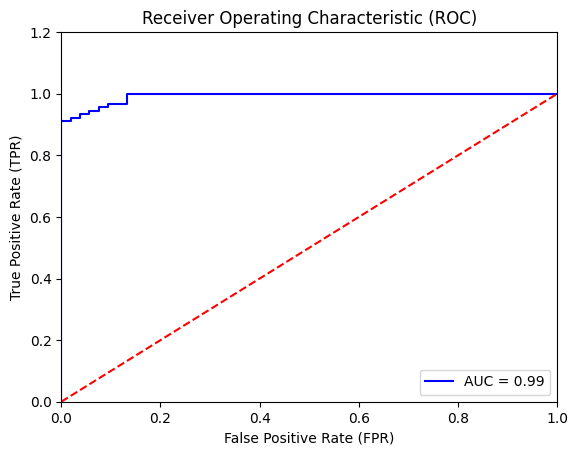

In [163]:
#---find the area under the curve---
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1.2])
plt.ylabel('True Positive Rate (TPR)')
plt.xlabel('False Positive Rate (FPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc = 'lower right')
plt.show()


<div dir="rtl">
سطح زیر منحنی ROC معیاری برای سودمندی یک آزمون به طور کلی است، جایی که مساحت بیشتر به معنای آزمون مفیدتر است و از سطوح زیر منحنی ROC برای مقایسه سودمندی آزمون‌ها استفاده می‌شود. به طور کلی، هدف الگوریتم با بالاترین AUC است.

## خلاصه

در این فصل، با الگوریتم یادگیری نظارت شده دیگری به نام رگرسیون لجستیک آشنا شدید. ابتدا در مورد تابع logit و نحوه تبدیل آن به تابع سیگموئید یاد گرفتید. سپس رگرسیون لجستیک را در مجموعه داده سرطان سینه اعمال کردید و از آن برای پیش‌بینی بدخیم یا خوش خیم بودن تومور استفاده کردید. مهمتر از همه، این فصل برخی از معیارهایی را که در تعیین اثربخشی یک الگوریتم یادگیری ماشین مفید هستند، مورد بحث قرار داد. علاوه بر این، در مورد اینکه منحنی ROC چیست، چگونه آن را رسم کنید و چگونه سطح زیر منحنی را محاسبه کنید، یاد گرفتید.
</div>